# Model Comparison & Evaluation

In this notebook, we will:

1. Load the engineered football dataset
2. Create a chronological train-test split
3. Train multiple classification models
4. Compare their performance
5. Analyze precision, recall and F1-score
6. Visualize confusion matrices
7. Identify the best-performing model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 1. Load the Feature-Engineered Dataset

The feature-engineered dataset contains historical team statistics calculated using only information available before each match.

This prevents information from the current match from leaking into the prediction features.

In [2]:
df = pd.read_csv("../data/processed/PremierLeague25_26_features.csv")

df.head()

,Date,HomeTeam,AwayTeam,HomeMatchesBefore,HomeGoalsForBefore,HomeGoalsAgainstBefore,HomePointsBefore,AwayMatchesBefore,AwayGoalsForBefore,AwayGoalsAgainstBefore,...,FTR,HomeAvgGoalsFor,HomeAvgGoalsAgainst,AwayAvgGoalsFor,AwayAvgGoalsAgainst,HomePointsPerMatch,AwayPointsPerMatch,AttackDifference,DefenseDifference,PointsDifference
0,2025-08-15,Liverpool,Bournemouth,0,0,0,0,0,0,0,...,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-08-16,Aston Villa,Newcastle,0,0,0,0,0,0,0,...,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-08-16,Brighton,Fulham,0,0,0,0,0,0,0,...,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-08-16,Sunderland,West Ham,0,0,0,0,0,0,0,...,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-08-16,Tottenham,Burnley,0,0,0,0,0,0,0,...,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.shape

(380, 21)

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df[["Date", "HomeTeam", "AwayTeam", "FTR"]].head()

,Date,HomeTeam,AwayTeam,FTR
0,2025-08-15,Liverpool,Bournemouth,H
1,2025-08-16,Aston Villa,Newcastle,D
2,2025-08-16,Brighton,Fulham,D
3,2025-08-16,Sunderland,West Ham,H
4,2025-08-16,Tottenham,Burnley,H


## 2. Select the Machine Learning Features

We will use the historical team-performance features created in Notebook 4.

We will not use match statistics such as:

- Full-time goals
- Half-time goals
- Shots
- Shots on target
- Corners
- Cards

because these are statistics from the match itself and would not be available before the result is known.

In [5]:
ml_features = [
    "HomeAvgGoalsFor",
    "HomeAvgGoalsAgainst",
    "AwayAvgGoalsFor",
    "AwayAvgGoalsAgainst",
    "HomePointsPerMatch",
    "AwayPointsPerMatch",
    "AttackDifference",
    "DefenseDifference",
    "PointsDifference"
]

X = df[ml_features]
y = df["FTR"]

In [6]:
X.head()

,HomeAvgGoalsFor,HomeAvgGoalsAgainst,AwayAvgGoalsFor,AwayAvgGoalsAgainst,HomePointsPerMatch,AwayPointsPerMatch,AttackDifference,DefenseDifference,PointsDifference
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
y.value_counts()

FTR
H    162
A    114
D    104
Name: count, dtype: int64

## 3. Chronological Train-Test Split

Because football matches happen over time, we will not randomly shuffle the dataset.

The first 80% of matches will be used for training and the final 20% for testing.

This better represents the real-world situation where we train on past matches and predict future matches.

In [8]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df[ml_features]
X_test = test_df[ml_features]

y_train = train_df["FTR"]
y_test = test_df["FTR"]

In [9]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 304
Testing samples: 76


In [10]:
print("Training period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

Training period:
2025-08-15 00:00:00 to 2026-03-21 00:00:00

Testing period:
2026-03-21 00:00:00 to 2026-05-24 00:00:00


## 4. Decision Tree Classifier

A Decision Tree makes predictions by repeatedly splitting the data based on feature values.

For example, the model may learn rules similar to:

- Is the home team's points-per-match advantage high?
- Is the home team's attacking performance better?
- Is the away team's defensive record strong?

Decision Trees are easy to interpret and provide a useful comparison against Logistic Regression.

In [11]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

In [12]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.3815789473684211


In [13]:
print(classification_report(
    y_test,
    dt_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           A       0.29      0.50      0.37        20
           D       0.00      0.00      0.00        20
           H       0.50      0.53      0.51        36

    accuracy                           0.38        76
   macro avg       0.26      0.34      0.29        76
weighted avg       0.31      0.38      0.34        76



## 5. Random Forest Classifier

Random Forest is an ensemble model made up of many Decision Trees.

Instead of relying on one tree, it combines predictions from multiple trees.

This generally makes the model more robust and less dependent on one particular set of decision rules.

In [14]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

In [15]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5131578947368421


In [16]:
print(classification_report(
    y_test,
    rf_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           A       0.38      0.30      0.33        20
           D       0.20      0.05      0.08        20
           H       0.58      0.89      0.70        36

    accuracy                           0.51        76
   macro avg       0.39      0.41      0.37        76
weighted avg       0.43      0.51      0.44        76



## 6. Gradient Boosting Classifier

Gradient Boosting builds models sequentially.

Each new model attempts to improve upon the errors made by the previous models.

It is a powerful model for structured/tabular datasets and provides another useful comparison with Logistic Regression, Decision Tree and Random Forest.

In [17]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

gb_predictions = gradient_boosting.predict(X_test)

In [18]:
gb_accuracy = accuracy_score(y_test, gb_predictions)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.47368421052631576


In [19]:
print(classification_report(
    y_test,
    gb_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           A       0.33      0.35      0.34        20
           D       0.30      0.15      0.20        20
           H       0.58      0.72      0.64        36

    accuracy                           0.47        76
   macro avg       0.40      0.41      0.39        76
weighted avg       0.44      0.47      0.45        76



## 7. Compare Model Accuracy

We will compare all models using the same test dataset.

In [20]:
# Baseline model
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)


# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)


# Compare all models
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
})

results

C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Model,Accuracy
0,Baseline,0.473684
1,Logistic Regression,0.552632
2,Decision Tree,0.381579
3,Random Forest,0.513158
4,Gradient Boosting,0.473684


In [21]:
results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy
0,Logistic Regression,0.552632
1,Random Forest,0.513158
2,Baseline,0.473684
3,Gradient Boosting,0.473684
4,Decision Tree,0.381579


## 8. Detailed Model Comparison

For multiclass classification, we will compare:

- Precision
- Recall
- F1-score

We will particularly look at macro F1-score because it gives equal importance to each class.

In [22]:
model_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gb_predictions
}

In [23]:
comparison = []

for model_name, predictions in model_predictions.items():
    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    comparison.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision (Macro)": report["macro avg"]["precision"],
        "Recall (Macro)": report["macro avg"]["recall"],
        "F1 (Macro)": report["macro avg"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Logistic Regression,0.552632,0.354167,0.433333,0.365000
1,Decision Tree,0.381579,0.264706,0.342593,0.294628
2,Random Forest,0.513158,0.385606,0.412963,0.372210
3,Gradient Boosting,0.473684,0.403704,0.407407,0.394480


In [24]:
comparison_df.sort_values(
    by="F1 (Macro)",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Gradient Boosting,0.473684,0.403704,0.407407,0.394480
1,Random Forest,0.513158,0.385606,0.412963,0.372210
2,Logistic Regression,0.552632,0.354167,0.433333,0.365000
3,Decision Tree,0.381579,0.264706,0.342593,0.294628


## 9. Confusion Matrices

A confusion matrix shows which classes the model predicted correctly and which classes it confused.

The three classes are:

- H = Home Win
- D = Draw
- A = Away Win

In [25]:
labels = ["H", "D", "A"]

cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=labels
)

cm_dt = confusion_matrix(
    y_test,
    dt_predictions,
    labels=labels
)

cm_rf = confusion_matrix(
    y_test,
    rf_predictions,
    labels=labels
)

cm_gb = confusion_matrix(
    y_test,
    gb_predictions,
    labels=labels
)

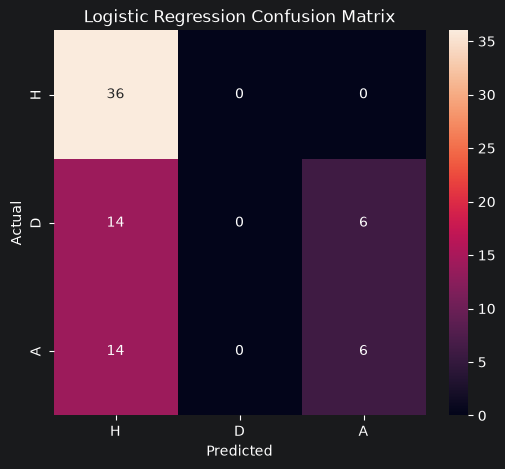

In [26]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

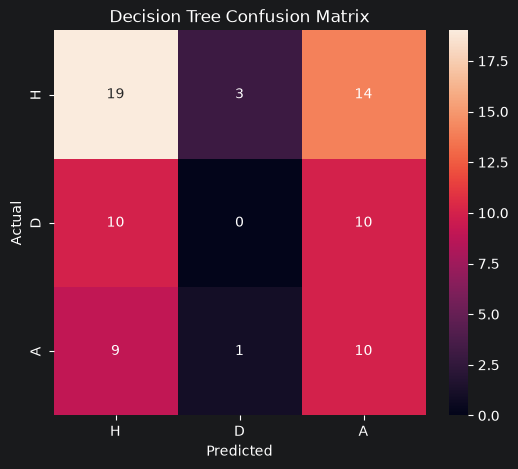

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

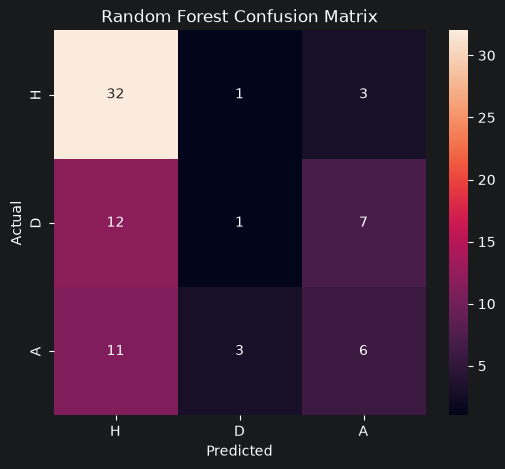

In [28]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

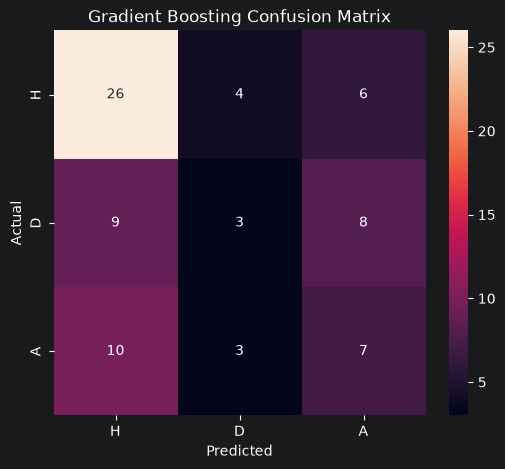

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.show()

## 10. Feature Importance

Tree-based models can estimate how important each feature was when making predictions.

We will inspect Random Forest feature importance.

This can help us understand which historical team-performance variables contributed most to the predictions.

In [30]:
feature_importance = pd.DataFrame({
    "Feature": ml_features,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,DefenseDifference,0.133937
6,AttackDifference,0.131881
8,PointsDifference,0.124939
1,HomeAvgGoalsAgainst,0.113782
2,AwayAvgGoalsFor,0.107198
0,HomeAvgGoalsFor,0.103213
3,AwayAvgGoalsAgainst,0.100457
5,AwayPointsPerMatch,0.093215
4,HomePointsPerMatch,0.091379


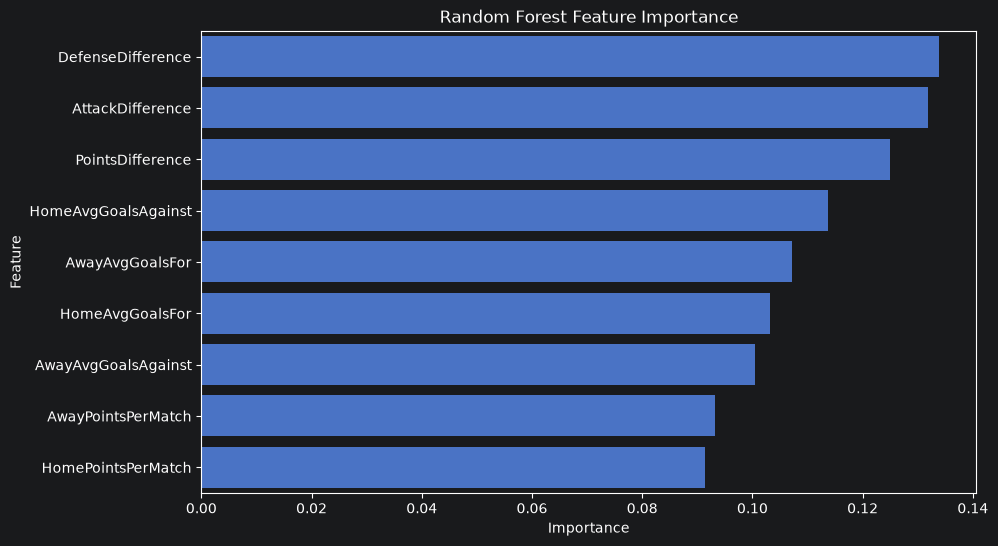

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 11. Selecting the Best Model

We will select the model based on multiple evaluation metrics rather than accuracy alone.

Important considerations include:

- Accuracy
- Macro precision
- Macro recall
- Macro F1-score
- Confusion matrix
- Model complexity
- Interpretability

In [32]:
comparison_df.sort_values(
    by="F1 (Macro)",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Gradient Boosting,0.473684,0.403704,0.407407,0.394480
1,Random Forest,0.513158,0.385606,0.412963,0.372210
2,Logistic Regression,0.552632,0.354167,0.433333,0.365000
3,Decision Tree,0.381579,0.264706,0.342593,0.294628


## 12. Evaluation Summary

The models were evaluated using a chronological train-test split.

The baseline model provides a minimum performance reference.

Logistic Regression provides a simple linear classification baseline.

Decision Tree, Random Forest and Gradient Boosting provide more flexible non-linear models.

The final model should be selected based on overall predictive performance and suitability for the project, rather than accuracy alone.